# PSet #4 – Optimización de Gastos de Marketing para Showz

In [1]:
import pandas as pd

## Paso 1: Acceso y preparación de los datos

In [2]:
visitas = pd.read_csv('../datasets/raw/visits_log_us.csv')
costos = pd.read_csv('../datasets/raw/cost_us.csv')
ordenes = pd.read_csv('../datasets/raw/orders_log_us.csv')

In [3]:
def exploracion_inicial(df):
    print('-' * 30 + 'Primeras 10 filas' + '-' * 30)
    print(df.head(10))
    print('-' * 30 + 'Estructura de la tabla' + '-' * 30)
    print(df.info())
    print('-' * 30 + 'Duplicados' + '-' * 30)
    print(df.duplicated().sum())
    print('-' * 30 + 'Ausentes' + '-' * 30)
    print(df.isna().sum())


### 1.1 Exploración inicial del dataset de visitas

In [4]:
exploracion_inicial(visitas)

------------------------------Primeras 10 filas------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6 

### Limpieza de columnas y conversión de fechas

In [5]:
# VISITAS

visitas.columns = [ columna.lower().replace(' ', '_') for columna in visitas.columns]

In [6]:
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])

In [7]:
visitas.value_counts('device')

device
desktop    262567
touch       96833
Name: count, dtype: int64

In [8]:
visitas.value_counts('source_id').sort_index()

source_id
1      34121
2      47626
3      85610
4     101794
5      66905
6          6
7         36
9      13277
10     10025
Name: count, dtype: int64

In [9]:
visitas['start_ts'].min()

Timestamp('2017-06-01 00:01:00')

In [10]:
visitas['start_ts'].max()

Timestamp('2018-05-31 23:59:00')

In [11]:
visitas['end_ts'].min()

Timestamp('2017-06-01 00:02:00')

In [12]:
visitas['end_ts'].max()

Timestamp('2018-06-01 01:26:00')

### 1.2 Exploración inicial del dataset de órdenes

In [13]:
# ORDENES

exploracion_inicial(ordenes)

------------------------------Primeras 10 filas------------------------------
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   1074355127080856382
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non

### Limpieza de columnas y conversión de fechas

In [14]:
ordenes.columns = [ columna.lower().replace(' ', '_') for columna in ordenes.columns]

In [15]:
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])

In [16]:
ordenes['buy_ts'].min()

Timestamp('2017-06-01 00:10:00')

In [17]:
ordenes['buy_ts'].max()

Timestamp('2018-06-01 00:02:00')

### 1.3 Exploración inicial del dataset de costos

In [18]:
# Costos

exploracion_inicial(costos)

------------------------------Primeras 10 filas------------------------------
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None
------------------------------Duplicados------------------------------
0
------------------------------Ausentes--

In [19]:
costos['date'] = pd.to_datetime(costos['dt'])
#costos.drop(['dt'], axis=1, inplace=True)

### Conclusiones preliminares de la exploración de datos

A partir del análisis inicial de los datasets proporcionados (`visitas`, `ordenes`, `costos`), se destacan los siguientes hallazgos clave:

- **Visitas:**
  - Se registraron un total de 359.400 sesiones entre el 1 de junio de 2017 y el 1 de junio de 2018.
  - El 73% de las visitas provienen de dispositivos `desktop` y el 27% de `touch`.
  - La mayoría del tráfico se concentra en pocas fuentes, destacando `source_id` 4, 3 y 5.
  - No se encontraron valores nulos ni duplicados, y las fechas están correctamente estructuradas.

- **Órdenes:**
  - Se procesaron 50.415 órdenes de compra durante el mismo periodo de análisis.
  - No hay registros duplicados ni nulos.
  - La conversión de fechas y estandarización de columnas se realizó correctamente, lo que permitirá estudiar el comportamiento de compra y calcular métricas como LTV y ticket promedio.

- **Costos:**
  - El dataset contiene 2.542 registros diarios de inversión en marketing distribuidos entre varias fuentes (`source_id`).
  - No se identificaron valores faltantes ni duplicados.
  - Las fechas de gasto coinciden con el rango temporal de los otros datasets, lo cual facilita su integración para calcular indicadores como CAC y ROMI.

### Guardado de datasets limpios

In [20]:
import os
os.makedirs('../datasets/interim/', exist_ok=True)

# Guardar versiones limpias
visitas.to_csv('../datasets/interim/visitas_limpias.csv', index=False)
ordenes.to_csv('../datasets/interim/ordenes_limpias.csv', index=False)
costos.to_csv('../datasets/interim/costos_limpios.csv', index=False)

In [21]:
costos.head()

,source_id,dt,costs,date
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-02
2,1,2017-06-03,36.53,2017-06-03
3,1,2017-06-04,55.00,2017-06-04
4,1,2017-06-05,57.08,2017-06-05


In [22]:
# Visitas

visitas['sesion_mes'] = pd.to_datetime(visitas['start_ts'].dt.strftime('%Y-%m-01'))
visitas['sesion_semana'] = visitas['start_ts'].dt.isocalendar().week
visitas['sesion_fecha'] = visitas['start_ts'].dt.date

In [23]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27


## Paso 2: Cálculo de métricas

### DAU - WAU - MAU

Estos indicadores permiten medir la frecuencia de uso de la plataforma:

- **DAU (Daily Active Users):** usuarios únicos por día.
- **WAU (Weekly Active Users):** usuarios únicos por semana.
- **MAU (Monthly Active Users):** usuarios únicos por mes.

In [25]:
dau = visitas.groupby('sesion_fecha').agg({'uid': 'nunique'})
wau = visitas.groupby('sesion_semana').agg({'uid': 'nunique'})
mau = visitas.groupby('sesion_mes').agg({'uid': 'nunique'})

#### Resultados – DAU, WAU, MAU

In [93]:
dau

,uid
sesion_fecha,
2017-06-01,605
2017-06-02,608
2017-06-03,445
2017-06-04,476
2017-06-05,820
...,...
2018-05-27,620
2018-05-28,1039
2018-05-29,948


In [94]:
wau

,uid
sesion_semana,
1,6918
2,6703
3,6972
4,7060
5,8111
6,7908
7,7759
8,7518
9,7395


In [95]:
mau

,uid
sesion_mes,
2017-06-01,13259
2017-07-01,14183
2017-08-01,11631
2017-09-01,18975
2017-10-01,29692
2017-11-01,32797
2017-12-01,31557
2018-01-01,28716
2018-02-01,28749


In [26]:
import matplotlib.pyplot as plt

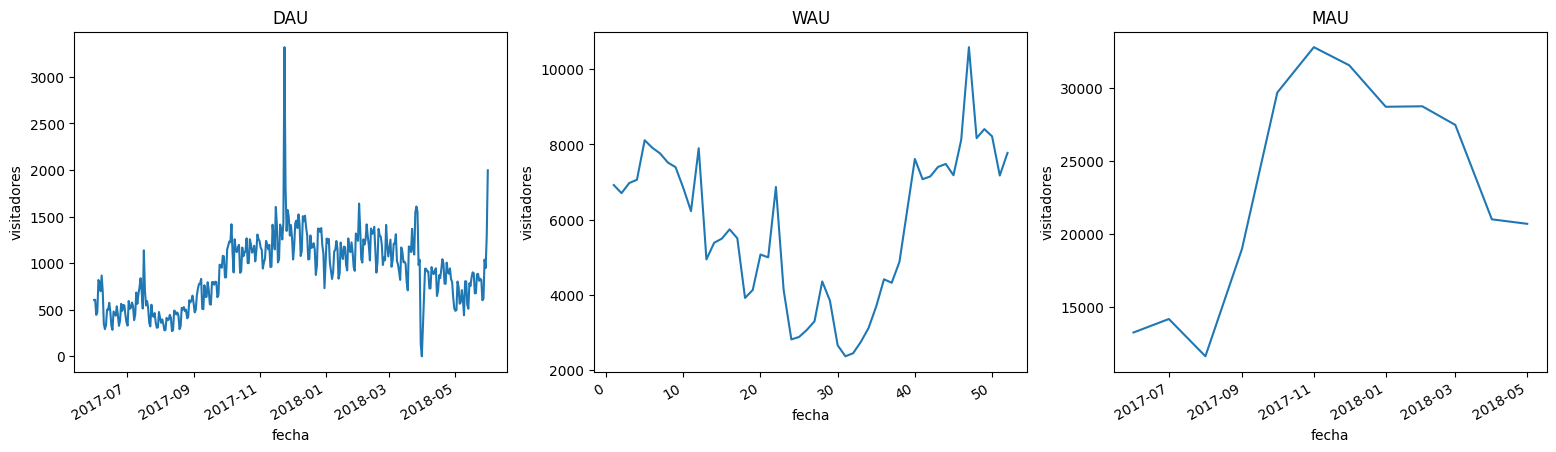

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(19,5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='fecha', ylabel='visitadores')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='fecha', ylabel='visitadores')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='fecha', ylabel='visitadores')
fig.autofmt_xdate(rotation=30)
plt.show()

### Sesiones por usuario

In [28]:
# Sesiones por usuario

sesiones_por_usuario = visitas.groupby('sesion_fecha').agg({'uid': ['count', 'nunique']})

In [29]:
sesiones_por_usuario.columns = ['n_sesiones', 'n_usuarios']

In [30]:
sesiones_por_usuario['sessiones_por_usuario'] = sesiones_por_usuario['n_sesiones'] / sesiones_por_usuario['n_usuarios']

<Axes: xlabel='sesion_fecha'>

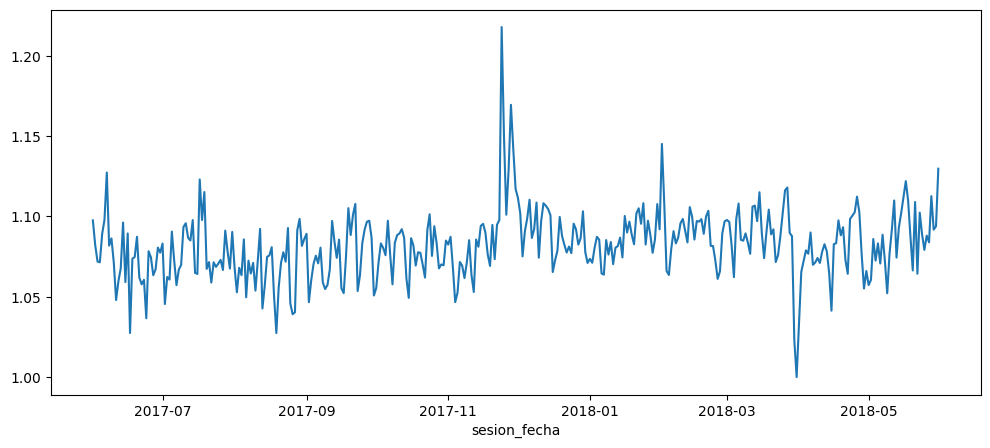

In [31]:
plt.figure(figsize=(12,5))
sesiones_por_usuario['sessiones_por_usuario'].plot()

In [32]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27


### Duración de cada sesión

In [33]:
visitas['duracion_sesion_seg'] = (visitas['end_ts'] - visitas['start_ts']).dt.seconds

In [34]:
visitas['duracion_sesion_seg']

0         1080
1         1680
2            0
3         1440
4            0
          ... 
359395      19
359396      19
359397      19
359398      19
359399      19
Name: duracion_sesion_seg, Length: 359400, dtype: int32

<Axes: >

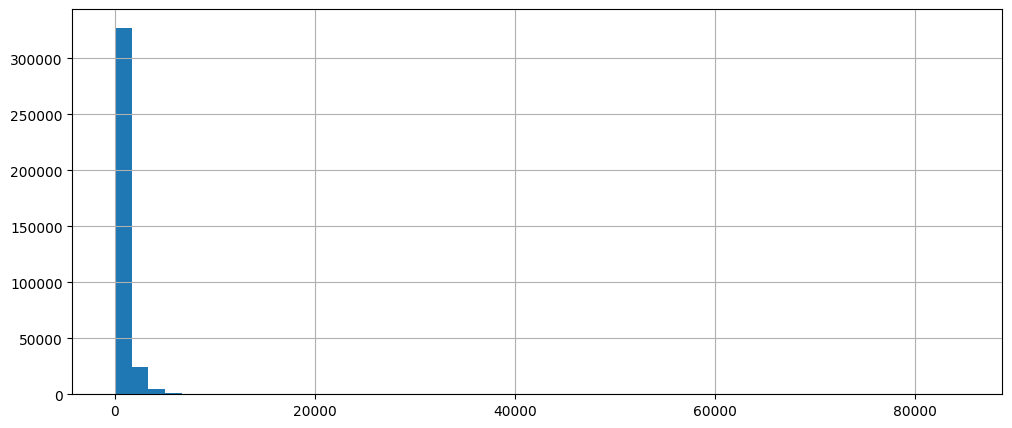

In [35]:
plt.figure(figsize=(12,5))
visitas['duracion_sesion_seg'].hist(bins=50)

In [36]:
visitas['duracion_sesion_seg'].mean()

np.float64(643.506488592098)

In [37]:
visitas['duracion_sesion_seg'].median()

np.float64(300.0)

### Frecuencia de Retorno

Para analizar el comportamiento de retorno de los usuarios, calculamos cuántas veces vuelve cada cliente después de su primera visita.

- **Promedio de retornos por usuario**
- **Mediana de retornos por usuario**
- **% de usuarios que regresaron al menos una vez:**

In [38]:
# Cual es el porcentaje de retencion de los usuarios
# Retention Rate

In [39]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27,0


In [40]:
primeras_visitas = visitas.groupby('uid').agg({'start_ts': 'min'}).reset_index()

In [41]:
primeras_visitas.columns = ['uid', 'inicio_primera_sesion_ts']

In [42]:
primeras_visitas['primera_sesion_fecha'] = primeras_visitas['inicio_primera_sesion_ts'].dt.date
primeras_visitas['primera_sesion_mes'] = pd.to_datetime(primeras_visitas['inicio_primera_sesion_ts'].dt.strftime('%Y-%m-01'))

In [43]:
primeras_visitas

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01
4,325320750514679,2017-09-30 14:29:00,2017-09-30,2017-09-01
...,...,...,...,...
228164,18446403737806311543,2017-11-30 03:36:00,2017-11-30,2017-11-01
228165,18446424184725333426,2017-12-06 20:32:00,2017-12-06,2017-12-01
228166,18446556406699109058,2018-01-01 16:29:00,2018-01-01,2018-01-01
228167,18446621818809592527,2017-12-27 13:27:00,2017-12-27,2017-12-01


In [44]:
visitas_full = pd.merge(primeras_visitas, visitas, on = 'uid', how='inner')

In [45]:
import numpy as np

In [46]:
visitas_full['edad_meses'] = ((visitas_full['sesion_mes'] - visitas_full['primera_sesion_mes']) / (30 * np.timedelta64(1, 'D'))).round().astype('int')

In [47]:
cohortes_visitas = visitas_full.pivot_table(
    index='primera_sesion_mes',
    columns='edad_meses',
    values='uid',
    aggfunc='nunique'
)

In [48]:
cohortes_visitas.fillna(0, inplace=True)

In [49]:
cohortes_visitas

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_sesion_mes,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,0.0
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,0.0,0.0
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,0.0,0.0,0.0
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,0.0,0.0,0.0,0.0
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,0.0,0.0,0.0,0.0,0.0
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-01,22197.0,1267.0,565.0,446.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
retention = pd.DataFrame()

In [51]:
for col in cohortes_visitas.columns:
    retention = pd.concat([retention, cohortes_visitas[col]/cohortes_visitas[0]], axis = 1)

In [52]:
retention.columns = cohortes_visitas.columns

In [53]:
retention.index = [str(indice)[:10] for indice in retention.index]

#### Visualización de la tasa de retención mensual

Se presenta a continuación un heatmap que muestra el porcentaje de usuarios que regresaron cada mes posterior a su primera visita. Cada fila representa una cohorte de usuarios que ingresaron por primera vez en un determinado mes, y cada columna representa el mes transcurrido desde su primera visita.

Esto permite identificar patrones de fidelización, así como períodos en los que la retención cae drásticamente.

[Text(0.5, 1.0, 'Ratio de retencion')]

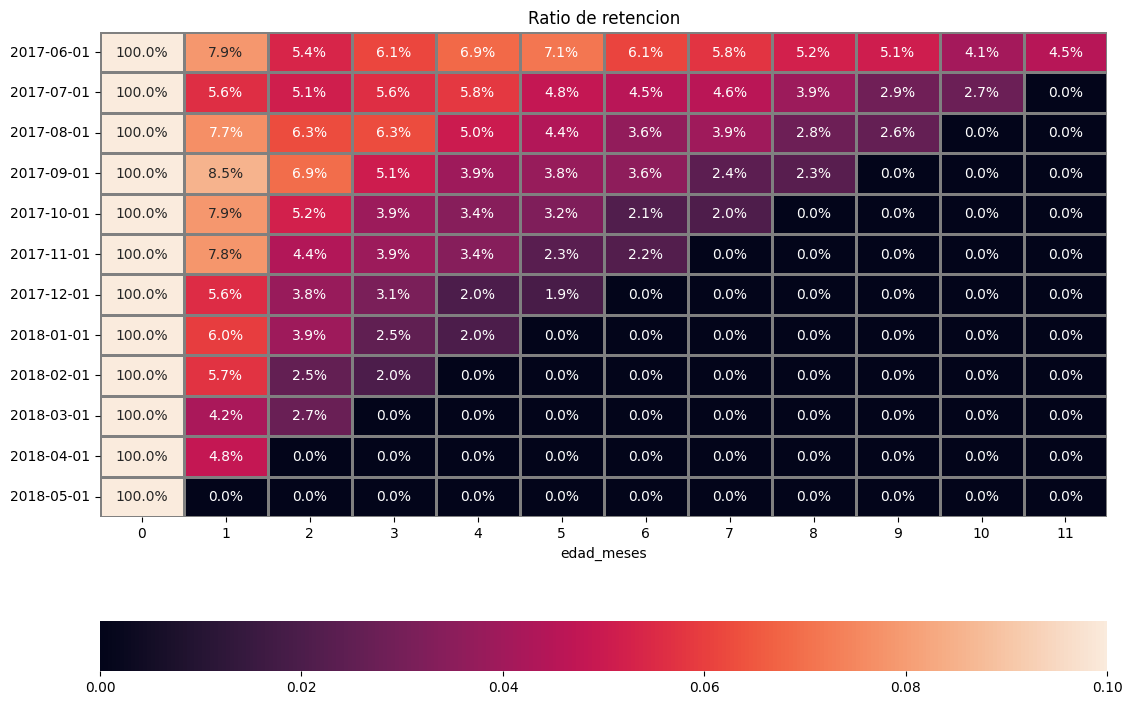

In [54]:
import seaborn as sns
plt.figure(figsize=(13,9))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1%',
    linewidths=1,
    linecolor='grey',
    vmax=0.1,
    cbar_kws={'orientation': 'horizontal'}
).set(title = 'Ratio de retencion')

#### Interpretación de resultados

Se observa que la retención tiende a disminuir con el paso del tiempo, como es esperable en la mayoría de plataformas digitales. Sin embargo, algunas cohortes muestran mayor fidelidad en los primeros meses, lo cual puede estar relacionado con campañas específicas o eventos de interés en esas fechas.

Este análisis permite a Showz identificar meses o fuentes de tráfico que generan usuarios más propensos a regresar, lo cual es clave para definir estrategias de marketing orientadas a la retención.

## B. Ventas

En esta sección se analiza el comportamiento de compra de los usuarios. Evaluaremos:
- Cuándo comienzan a comprar los usuarios después de registrarse (B.1),
- La frecuencia y cantidad de pedidos realizados (B.2),
- El tamaño promedio de compra o ticket promedio (B.3),
- Y el valor total que cada cliente genera a lo largo del tiempo (Lifetime Value, B.4).

In [55]:
# Cuando los clientes empiezas a comprar?

In [56]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


### B.1 ¿Cuándo empieza la gente a comprar?

El objetivo de este análisis es determinar cuánto tiempo transcurre desde la primera visita del usuario hasta su primera compra.

In [57]:
ordenes['compra_mes'] = pd.to_datetime(ordenes['buy_ts'].dt.strftime('%Y-%m-01'))

In [58]:
primeras_compras = ordenes.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

In [59]:
primeras_compras.columns = ['uid', 'primera_compra']

In [60]:
primeras_compras['primera_compra_fecha'] = primeras_compras['primera_compra'].dt.date

In [61]:
primeras_compras['primera_compra_mes'] = pd.to_datetime(primeras_compras['primera_compra'].dt.strftime('%Y-%m-01'))

In [62]:
compradores = pd.merge(primeras_visitas, primeras_compras, on = 'uid')

In [63]:
compradores

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes,primera_compra,primera_compra_fecha,primera_compra_mes
0,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,2018-01-03 21:51:00,2018-01-03,2018-01-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06-01,2017-06-03 10:13:00,2017-06-03,2017-06-01
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,2017-10-01,2017-10-11 18:33:00,2017-10-11,2017-10-01
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,2018-01-01,2018-01-28 15:54:00,2018-01-28,2018-01-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11-01,2017-11-24 10:14:00,2017-11-24,2017-11-01
...,...,...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-08-20,2017-08-01,2017-11-24 09:03:00,2017-11-24,2017-11-01
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22,2017-09-01,2017-09-22 23:55:00,2017-09-22,2017-09-01
36520,18445601152732270159,2017-08-07 11:51:00,2017-08-07,2017-08-01,2018-03-26 22:54:00,2018-03-26,2018-03-01
36521,18446156210226471712,2017-11-07 10:01:00,2017-11-07,2017-11-01,2018-02-18 19:34:00,2018-02-18,2018-02-01


A continuación, calculamos cuántos días pasan entre la primera visita de un usuario y su primera compra. Esta métrica es clave para entender el tiempo de conversión de nuestros clientes potenciales.

In [64]:
# Cuanto dias pasan hasta la primera compra (desde la primera visita)?

In [65]:
compradores['dias_hasta_la_primera_compra'] = ((compradores['primera_compra'] - compradores['inicio_primera_sesion_ts']) / np.timedelta64(1, 'D')).astype('int')

In [66]:
compradores['dias_hasta_la_primera_compra']

0        106
1          0
2          0
3          0
4          0
        ... 
36518     95
36519      0
36520    231
36521    103
36522      0
Name: dias_hasta_la_primera_compra, Length: 36523, dtype: int64

Como se observa, muchos usuarios compran el mismo día de su primera visita (0 días), mientras que otros pueden tardar desde unos pocos días hasta varios meses. Esta información nos ayudará a categorizar los patrones de conversión.

In [67]:
import plotly.express as px

In [68]:
px.histogram(compradores['dias_hasta_la_primera_compra'])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'bingroup': 'x',
              'hovertemplate': 'variable=dias_hasta_la_primera_compra<br>value=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'dias_hasta_la_primera_compra',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'dias_hasta_la_primera_compra',
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': {'bdata': ('agAAAAAAAAAAAAAAJAAAAAAAAAAYAA' ... 'AAAAAAAHIAJwAAAF8AAADnAGcAAAA='),
                    'dtype': 'i2'},
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'title': {'text': 'variable'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'value'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [69]:
# Como se ven las compras por cohorte

In [70]:
# Encontrar el numero de clientes por cada cohorte

In [71]:
tamano_cohorte = compradores.groupby('primera_compra_mes').agg({'uid': 'nunique'}).reset_index()

In [72]:
tamano_cohorte.columns = ['primera_compra_mes', 'n_compradores']

In [73]:
cohortes = pd.merge(ordenes, compradores, how='inner', on='uid')

In [74]:
cohortes = cohortes.groupby(['primera_compra_mes', 'compra_mes']).agg({'uid':'count', 'revenue': 'sum'}).reset_index()

In [75]:
cohortes['edad_meses'] = ((cohortes['compra_mes'] - cohortes['primera_compra_mes'])/(30*np.timedelta64(1, 'D'))).round().astype('int')

In [76]:
cohortes.columns = ['primera_compra_mes', 'compra_mes', 'n_ordenes', 'venta_total', 'edad_meses']

In [77]:
cohortes

,primera_compra_mes,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2017-06-01,2354,9557.49,0
1,2017-06-01,2017-07-01,177,981.82,1
2,2017-06-01,2017-08-01,174,885.34,2
3,2017-06-01,2017-09-01,226,1931.30,3
4,2017-06-01,2017-10-01,292,2068.58,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,176,1114.87,2
75,2018-04-01,2018-04-01,2495,10600.69,0
76,2018-04-01,2018-05-01,195,1209.92,1
77,2018-05-01,2018-05-01,3249,13925.76,0


### B.2 ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [102]:
# B.2: contar pedidos por mes
pedidos_por_mes = ordenes.groupby(ordenes['buy_ts'].dt.to_period('M')).size().reset_index(name='n_pedidos')
pedidos_por_mes['mes'] = pedidos_por_mes['buy_ts'].dt.to_timestamp()
pedidos_por_mes

,buy_ts,n_pedidos,mes
0,2017-06,2354,2017-06-01
1,2017-07,2363,2017-07-01
2,2017-08,1807,2017-08-01
3,2017-09,3387,2017-09-01
4,2017-10,5679,2017-10-01
5,2017-11,5659,2017-11-01
6,2017-12,6218,2017-12-01
7,2018-01,4721,2018-01-01
8,2018-02,5281,2018-02-01
9,2018-03,5326,2018-03-01


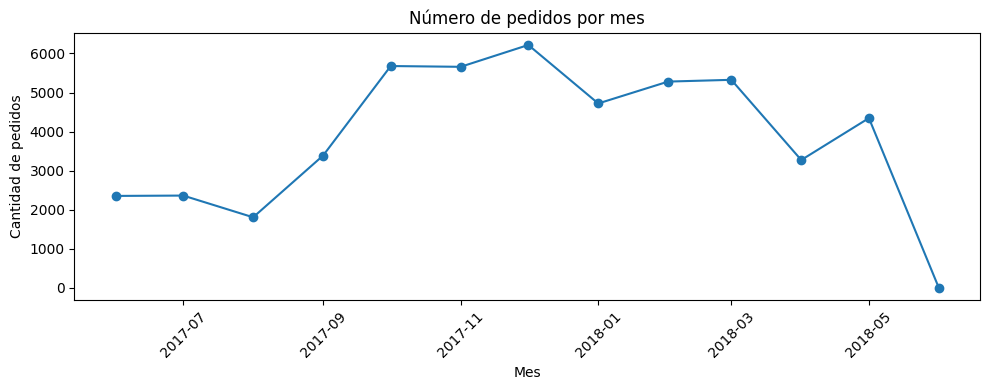

In [104]:
plt.figure(figsize=(10,4))
plt.plot(pedidos_por_mes['mes'], pedidos_por_mes['n_pedidos'], marker='o')
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### B.3) ¿Cuál es el tamaño promedio de compra? (Ticket promedio)
Calculamos el ticket promedio dividiendo las ventas totales por el número de órdenes realizadas en cada cohorte y mes. Este indicador permite conocer cuánto gasta, en promedio, cada cliente por pedido.

In [98]:
cohortes['ticket_promedio'] = cohortes['venta_total'] / cohortes['n_ordenes']
cohortes[['primera_compra_mes', 'edad_meses', 'ticket_promedio']].head()

,primera_compra_mes,edad_meses,ticket_promedio
0,2017-06-01,0,4.060106
1,2017-06-01,1,5.547006
2,2017-06-01,2,5.088161
3,2017-06-01,3,8.545575
4,2017-06-01,4,7.084178


In [99]:
ticket_pivot = cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ticket_promedio',
    aggfunc='mean'
)

[Text(0.5, 1.0, 'Ticket promedio por cohorte y edad')]

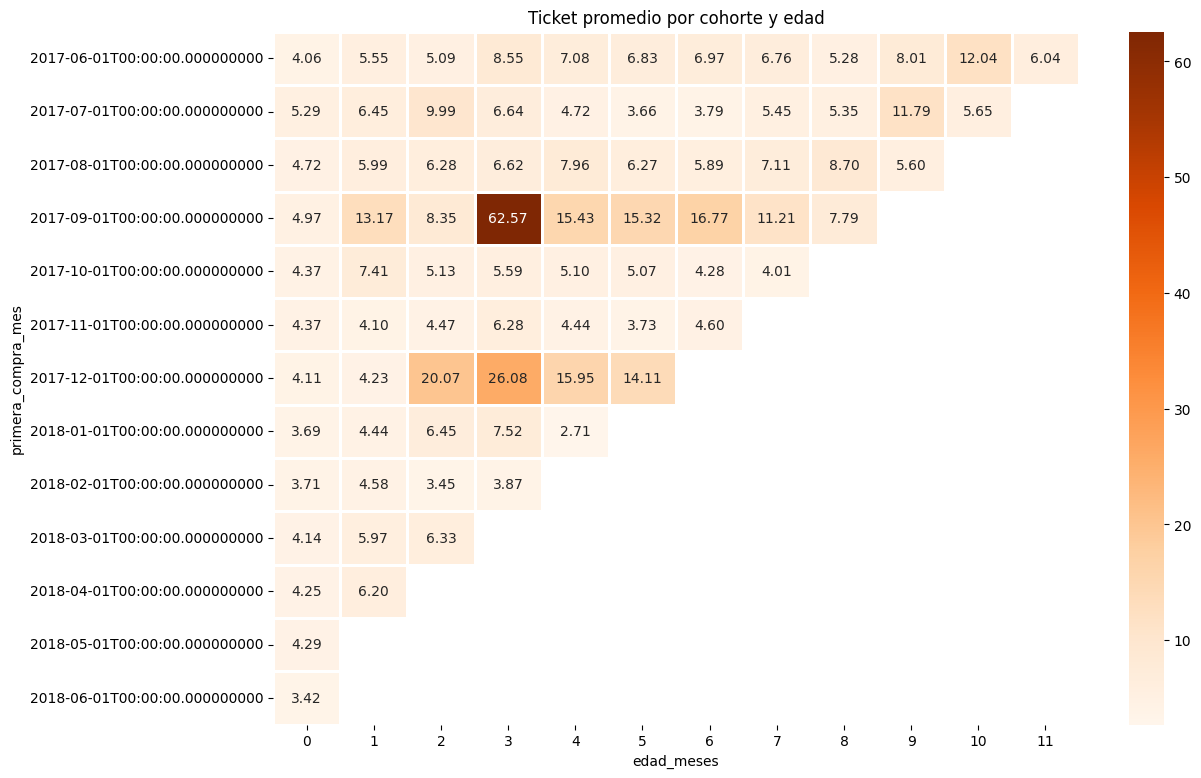

In [101]:
plt.figure(figsize=(13,9))
sns.heatmap(
    ticket_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    cmap='Oranges'
).set(title='Ticket promedio por cohorte y edad')

In [78]:
# Customer Lifetime Value

In [79]:
tamano_cohorte

,primera_compra_mes,n_compradores
0,2017-06-01,2023
1,2017-07-01,1923
2,2017-08-01,1370
3,2017-09-01,2581
4,2017-10-01,4340
5,2017-11-01,4081
6,2017-12-01,4383
7,2018-01-01,3373
8,2018-02-01,3651
9,2018-03-01,3533


In [80]:
cohortes

,primera_compra_mes,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2017-06-01,2354,9557.49,0
1,2017-06-01,2017-07-01,177,981.82,1
2,2017-06-01,2017-08-01,174,885.34,2
3,2017-06-01,2017-09-01,226,1931.30,3
4,2017-06-01,2017-10-01,292,2068.58,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,176,1114.87,2
75,2018-04-01,2018-04-01,2495,10600.69,0
76,2018-04-01,2018-05-01,195,1209.92,1
77,2018-05-01,2018-05-01,3249,13925.76,0


In [81]:
reporte_cohortes = pd.merge(tamano_cohorte, cohortes, how='inner', on='primera_compra_mes')

In [82]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2023,2017-06-01,2354,9557.49,0
1,2017-06-01,2023,2017-07-01,177,981.82,1
2,2017-06-01,2023,2017-08-01,174,885.34,2
3,2017-06-01,2023,2017-09-01,226,1931.30,3
4,2017-06-01,2023,2017-10-01,292,2068.58,4
...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2
75,2018-04-01,2276,2018-04-01,2495,10600.69,0
76,2018-04-01,2276,2018-05-01,195,1209.92,1
77,2018-05-01,2988,2018-05-01,3249,13925.76,0


### Métrica complementaria: Órdenes por comprador
Para entender la frecuencia de compra, se calcula el promedio de órdenes por cliente dentro de cada cohorte y mes. Esta métrica complementa el análisis del LTV, ya que permite observar cuán activos son los clientes a lo largo del tiempo.

In [83]:
reporte_cohortes['ordenes_por_comprador'] = reporte_cohortes['n_ordenes'] / reporte_cohortes['n_compradores']

In [84]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses,ordenes_por_comprador
0,2017-06-01,2023,2017-06-01,2354,9557.49,0,1.163618
1,2017-06-01,2023,2017-07-01,177,981.82,1,0.087494
2,2017-06-01,2023,2017-08-01,174,885.34,2,0.086011
3,2017-06-01,2023,2017-09-01,226,1931.30,3,0.111715
4,2017-06-01,2023,2017-10-01,292,2068.58,4,0.144340
...,...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2,0.049816
75,2018-04-01,2276,2018-04-01,2495,10600.69,0,1.096221
76,2018-04-01,2276,2018-05-01,195,1209.92,1,0.085677
77,2018-05-01,2988,2018-05-01,3249,13925.76,0,1.087349


### Construcción del Customer Lifetime Value (LTV)

El LTV se construye a partir del promedio de órdenes por comprador en cada cohorte a lo largo de los meses.
El objetivo es entender cuánto valor (en términos de órdenes) aporta un cliente a lo largo del tiempo desde su primera compra.

In [85]:
# Primera version del LTV

In [86]:
cohortes_ltv_1 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ordenes_por_comprador',
    aggfunc='sum'
)

In [87]:
cohortes_ltv_1.round(2).fillna(0, inplace=True)

### Visualización del LTV por cohorte

La siguiente tabla muestra el LTV acumulado por cohorte y por mes de antigüedad (edad).
Este análisis permite identificar patrones de comportamiento de compra a lo largo del tiempo.

In [88]:
cohortes_ltv_1

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,1.163618,0.087494,0.086011,0.111715,0.144340,0.107761,0.136431,0.086011,0.104795,0.075630,0.047454,0.042511
2017-07-01,1.136765,0.052002,0.062402,0.054082,0.037441,0.042642,0.031721,0.026001,0.030161,0.012480,0.027561,NaN
2017-08-01,1.118978,0.078832,0.072993,0.059124,0.062044,0.045255,0.035766,0.056934,0.033577,0.033577,NaN,NaN
2017-09-01,1.136381,0.084851,0.062379,0.063541,0.025959,0.042232,0.041844,0.021697,0.023634,NaN,NaN,NaN
2017-10-01,1.143779,0.072350,0.037327,0.028111,0.029724,0.023733,0.019816,0.028802,NaN,NaN,NaN,NaN
2017-11-01,1.179368,0.097280,0.044597,0.051703,0.033325,0.014457,0.024994,NaN,NaN,NaN,NaN,NaN
2017-12-01,1.152635,0.061602,0.046087,0.040840,0.019621,0.023956,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,1.121554,0.066410,0.047139,0.018974,0.023125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,1.121611,0.060805,0.022733,0.019173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses,ordenes_por_comprador
0,2017-06-01,2023,2017-06-01,2354,9557.49,0,1.163618
1,2017-06-01,2023,2017-07-01,177,981.82,1,0.087494
2,2017-06-01,2023,2017-08-01,174,885.34,2,0.086011
3,2017-06-01,2023,2017-09-01,226,1931.30,3,0.111715
4,2017-06-01,2023,2017-10-01,292,2068.58,4,0.144340
...,...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2,0.049816
75,2018-04-01,2276,2018-04-01,2495,10600.69,0,1.096221
76,2018-04-01,2276,2018-05-01,195,1209.92,1,0.085677
77,2018-05-01,2988,2018-05-01,3249,13925.76,0,1.087349


### LTV Monetario (versión 2)

Para obtener una versión más útil del Customer Lifetime Value (LTV), se calcula el ingreso promedio por comprador dividiendo el total de ventas entre el número de compradores de cada cohorte.

Esta métrica refleja en dólares cuánto valor genera en promedio un cliente a lo largo de los meses desde su primera compra.

In [90]:
reporte_cohortes['ltv'] = reporte_cohortes['venta_total'] / reporte_cohortes['n_compradores']

In [91]:
cohortes_ltv_2 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ltv',
    aggfunc='sum'
)

### Visualización del LTV en dólares por cohorte y edad

La siguiente tabla muestra el valor monetario promedio acumulado por cliente según su cohorte de ingreso y el tiempo transcurrido (edad en meses).
Esta matriz permite identificar patrones de valor generado por los clientes a lo largo del tiempo.

In [92]:
cohortes_ltv_2

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,4.724414,0.485329,0.437637,0.954671,1.022531,0.735502,0.950440,0.581592,0.553213,0.605788,0.571261,0.256856
2017-07-01,6.010218,0.335211,0.623531,0.358976,0.176791,0.156048,0.120208,0.141820,0.161232,0.147145,0.155673,NaN
2017-08-01,5.276518,0.471993,0.458482,0.391277,0.494051,0.283540,0.210664,0.405007,0.292212,0.187978,NaN,NaN
2017-09-01,5.644529,1.117586,0.520930,3.975792,0.400558,0.647067,0.701608,0.243150,0.184006,NaN,NaN,NaN
2017-10-01,5.003733,0.535763,0.191394,0.157145,0.151560,0.120362,0.084816,0.115470,NaN,NaN,NaN,NaN
2017-11-01,5.154683,0.399233,0.199556,0.324952,0.148013,0.053879,0.114928,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.738191,0.260374,0.925097,1.065275,0.312930,0.338047,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,4.135636,0.294758,0.304281,0.142778,0.062698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,4.156987,0.278274,0.078515,0.074144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## C. Marketing